# MULTIPLE - SVM vs Hybrid Spectral Net

In [ ]:
%%capture
!python -m pip install "abraia[multiple]"

import os
if not os.getenv('ABRAIA_ID') or not os.getenv('ABRAIA_KEY'):
    #@markdown <a href="https://abraia.me/editor/" target="_blank">Get your Abraia Id and Key</a>
    abraia_id = ''  #@param {type: "string"}
    abraia_key = ''  #@param {type: "string"}
    %env ABRAIA_ID=$abraia_id
    %env ABRAIA_KEY=$abraia_key

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from abraia.multiple import Multiple, hsi

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100
 
multiple = Multiple()

2023-04-07 17:43:00.910973: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-04-07 17:43:00.934194: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-04-07 17:43:01.048413: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-04-07 17:43:01.049743: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-07 17:43:01.825193: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

## Data loading

In [ ]:
dataset = 'IP'
X, y, class_names = hsi.load_dataset(dataset)
hsi.plot_images([hsi.principal_components(X, 1), y], ['HSI Image', 'Ground truth'])

In [3]:
print(f'HSI image size (width, height, bands): {X.shape}')
summary = pd.DataFrame([{'class_name': label, 'samples': np.sum(y == val)} for val, label in enumerate(class_names)])
summary.iloc[1:]

HSI image size (width, height, bands): (145, 145, 200)


,class_name,samples
1,Alfalfa,46
2,Corn-notill,1428
3,Corn-mintill,830
4,Corn,237
5,Grass-pasture,483
6,Grass-trees,730
7,Grass-pasture-mowed,28
8,Hay-windrowed,478
9,Oats,20
10,Soybean-notill,972


## SVM training and validation

In [ ]:
model = hsi.create_model('svm')
y_test, y_pred = model.train(X, y, train_ratio=0.7)

print('Overall accuracy', hsi.accuracy_score(y_test, y_pred))
print(hsi.classification_report(y_test, y_pred, target_names=class_names))
print(hsi.confusion_matrix(y_test, y_pred))

Overall accuracy 0.7682308180088776
                              precision    recall  f1-score   support

                                   0.81      0.85      0.83      3233
                     Alfalfa       1.00      0.64      0.78        14
                 Corn-notill       0.69      0.67      0.68       428
                Corn-mintill       0.78      0.66      0.72       249
                        Corn       0.60      0.51      0.55        71
               Grass-pasture       0.86      0.76      0.81       145
                 Grass-trees       0.83      0.78      0.80       219
         Grass-pasture-mowed       0.57      0.50      0.53         8
               Hay-windrowed       0.87      0.91      0.89       143
                        Oats       0.67      0.33      0.44         6
              Soybean-notill       0.70      0.67      0.69       292
             Soybean-mintill       0.75      0.75      0.75       737
               Soybean-clean       0.77      0.65    

<Figure size 1200x600 with 0 Axes>

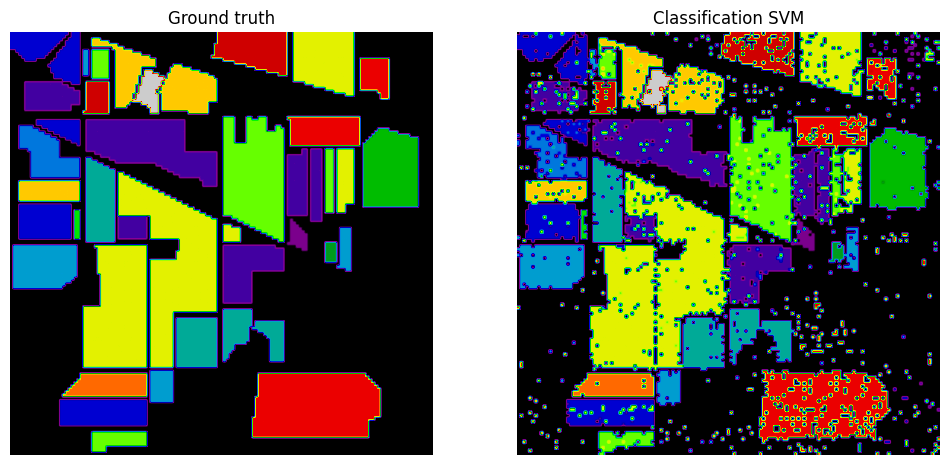

In [ ]:
clmap = model.predict(X)

hsi.plot_images([gt, clmap], ['Ground truth', 'Classification SVM'])

## HSN training and validation

In [4]:
patch_size = 25
K = 30 if dataset == 'IP' else 15

model = hsi.create_model('hsn', (patch_size, patch_size, K), len(class_names))
y_test, y_pred = model.train(X, y, train_ratio=0.5, epochs=20)
model.plot_history()

print('Overall accuracy', hsi.accuracy_score(y_test, y_pred))
print(hsi.classification_report(y_test, y_pred, target_names=class_names))
print(hsi.confusion_matrix(y_test, y_pred))

ValueError: Data cardinality is ambiguous:
  x sizes: 315360
  y sizes: 10512
Make sure all arrays contain the same number of samples.

(-0.5, 144.5, 144.5, -0.5)

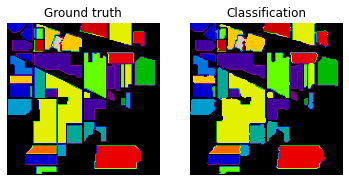

In [ ]:
output = model.predict(X)
hsi.plot_images([y, output], ['Ground truth', 'Classification'])